<a href="https://colab.research.google.com/github/Omar-Zantot/Hybrid-Soft-Computing/blob/main/Hybrid_Soft_Computing_Models_for_Diabetes_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a id="1"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">1 | Introduction</div>

<a id="1.1"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>1.1 | Problem</b> statement

Early diagnosis is critical for many diseases, especially **diabetes**, which is increasing in prevalence globally. According to the **World Health Organization (WHO)**, by 2030, **1 in 10 adults** will be affected by diabetes. Early detection allows for **better management** and **prevention** of complications such as kidney failure, heart disease, and blindness. Traditional methods like **clinical assessments**, **laboratory tests**, and **imaging** can sometimes fail to detect diseases early enough, particularly when symptoms are **subclinical** or **ambiguous**. This leads to the necessity for **advanced computational models** that can **predict diseases early** using complex, high-dimensional data.

<a id="1.2"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>1.2 Objective of the Study</b>

While traditional **single models** (like **ANN**, **SVM**, and **Decision Trees**) have proven effective for disease prediction, they often fall short when dealing with **uncertain**, **noisy**, or **incomplete data**. In healthcare, data is often **incomplete** (e.g., missing values), **noisy** (e.g., inaccurate records), and **uncertain** (e.g., subjective symptom reporting). This is where **hybrid soft computing models** come in. These models combine multiple techniques (e.g., **fuzzy logic**, **ANNs**, **genetic algorithms**) to enhance accuracy, robustness, and **generalization** in disease detection.

<a id="1.3"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>1.3 Focus of the Comparative Study</b>

This study will focus on comparing **single models** and **hybrid models** for **diabetes prediction**. We will evaluate **five algorithms** in total, considering both **single** and **hybrid models**. The comparison will be based on performance metrics such as **accuracy**, **precision**, **recall**, **F1-score**, and **AUC-ROC**. By using **shared datasets**, we will ensure that the comparison is fair and consistent across different model types. Our goal is to demonstrate how **hybrid models** can **outperform** single models, particularly in terms of handling the **complexity**, **uncertainty**, and **multimodal data** typically found in healthcare data.


<a id="2"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">2 | Importing Libraries</div>

In [1]:
import joblib
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



<a id="3"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">3 | Dataset Preparation </div>

<a id="3.1"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>3.1 | Dataset Description </b>

In this project, we are using the **Pima Indians Diabetes Dataset**, which is a widely used dataset for diabetes prediction. It contains several important features that help in predicting whether a patient has diabetes or not, based on various medical parameters.

The dataset has **8 feature columns** along with the target column **Outcome**, which indicates whether a person has diabetes (1) or not (0). Here's a quick overview of the columns:

<table style="width: 100%; border-collapse: collapse;">
  <thead>
    <tr>
      <th style="min-width: 10px; width: 30px; background-color: #333333; color: white; font-weight: bold; text-align: left; padding: 8px;">No</th>
      <th style="background-color: #333333; color: white; font-weight: bold; text-align: left; padding: 8px;">Column Name</th>
      <th style="background-color: #333333; color: white; font-weight: bold; text-align: left; padding: 8px;">Meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #254441; text-align: left;">1</td>
      <td style="font-weight: bold; font-size: 14px; color: #254441; text-align: left;">Pregnancies</td>
      <td style="font-size: 14px; text-align: left;">Number of pregnancies</td>
    </tr>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #3850A0; text-align: left;">2</td>
      <td style="font-weight: bold; font-size: 14px; color: #3850A0; text-align: left;">Glucose</td>
      <td style="font-size: 14px; text-align: left;">Glucose level in blood</td>
    </tr>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #8C001A; text-align: left;">3</td>
      <td style="font-weight: bold; font-size: 14px; color: #8C001A; text-align: left;">BloodPressure</td>
      <td style="font-size: 14px; text-align: left;">Blood pressure measurement</td>
    </tr>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #FFAA33; text-align: left;">4</td>
      <td style="font-weight: bold; font-size: 14px; color: #FFAA33; text-align: left;">SkinThickness</td>
      <td style="font-size: 14px; text-align: left;">Thickness of the skin</td>
    </tr>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #FF0077; text-align: left;">5</td>
      <td style="font-weight: bold; font-size: 14px; color: #FF0077; text-align: left;">Insulin</td>
      <td style="font-size: 14px; text-align: left;">Insulin level in blood</td>
    </tr>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #009A80; text-align: left;">6</td>
      <td style="font-weight: bold; font-size: 14px; color: #009A80; text-align: left;">BMI</td>
      <td style="font-size: 14px; text-align: left;">Body mass index</td>
    </tr>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #660099; text-align: left;">7</td>
      <td style="font-weight: bold; font-size: 14px; color: #660099; text-align: left;">DiabetesPedigreeFunction</td>
      <td style="font-size: 14px; text-align: left;">Diabetes percentage</td>
    </tr>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #4B0082; text-align: left;">8</td>
      <td style="font-weight: bold; font-size: 14px; color: #4B0082; text-align: left;">Age</td>
      <td style="font-size: 14px; text-align: left;">Age</td>
    </tr>
    <tr>
      <td style="font-weight: bold; font-size: 14px; color: #0000FF; text-align: left;">9</td>
      <td style="font-weight: bold; font-size: 14px; color: #0000FF; text-align: left;">Outcome</td>
      <td style="font-size: 14px; text-align: left;">Final result (<font color="#008000">1</font>: Yes, the individual has diabetes; <font color="#FF0000">0</font>: No, the individual does not have diabetes)</td>
    </tr>
  </tbody>
</table>

<a id="3.2"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>3.2 | Understanding the Dataset </b>

In the Pima Indians Diabetes Dataset, each row represents an individual patient with 8 attributes. These attributes are crucial for predicting whether a patient has diabetes or not based on their medical data. The **Outcome** column is the target variable, where `1` indicates that the patient has diabetes, and `0` indicates that the patient does not.

Here is a summary of the **features** and their significance:

- **Pregnancies**: This feature indicates the number of pregnancies the individual has had, which can be relevant for women as gestational diabetes is a risk factor for developing type 2 diabetes later in life.
- **Glucose**: The level of glucose in the blood, which is a direct indicator of diabetes. High blood glucose levels are a hallmark of diabetes.
- **BloodPressure**: Blood pressure measurement, which is important as hypertension is often associated with diabetes and can exacerbate the complications of diabetes.
- **SkinThickness**: This refers to the thickness of the skin, which can be used as a proxy for body fat in some models. Higher body fat percentage is often associated with an increased risk of type 2 diabetes.
- **Insulin**: The level of insulin in the blood, which is crucial for managing blood sugar. Low insulin production is one of the causes of diabetes.
- **BMI**: Body Mass Index, which is a key indicator of obesity. Obesity is a major risk factor for diabetes.
- **DiabetesPedigreeFunction**: A measure of the genetic predisposition to diabetes. This feature helps capture hereditary factors related to diabetes.
- **Age**: Age is an important factor because the risk of developing type 2 diabetes increases as people age.

<a id="3.3"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>3.3 | Read</b> dataset

In [2]:
df = pd.read_csv('/content/diabetes.csv')

<a id="3.4"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>3.4 | Some</b> information

> <span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>3.4.1 | Display data content</b></span>


In [ ]:
styled_df = df.head(5).style \
    .set_table_styles([
        {"selector": "th", "props": [
            ("color", '#FFDA7D'),
            ("background-color", "#1B3A4B"),
            ("font-weight", "bold"),
            ("text-align", "left"),
            ("padding", "10px"),
            ("border-bottom", "2px solid #FFDA7D")
        ]},
        {"selector": "td", "props": [
            ("padding", "10px"),
            ("border-bottom", "1px solid #FFDA7D")
        ]},
        {"selector": "tbody tr:hover td", "props": [
            ("background-color", "#2F5D6F")
        ]}
    ]) \
    .set_properties(**{
        "font-size": "15px",
        "background-color": "#254E58",
        "color": "#FFDA7D",
        "border": "1px solid #FFDA7D",
        "border-collapse": "collapse",
        "margin": "10px"
    })

styled_df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600000,0.627000,50,1
1,1,85,66,29,0,26.600000,0.351000,31,0
2,8,183,64,0,0,23.300000,0.672000,32,1
3,1,89,66,23,94,28.100000,0.167000,21,0
4,0,137,40,35,168,43.100000,2.288000,33,1


> <span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>3.4.2 |
Number of rows, number of columns</b></span>

In [4]:
rows , col =  df.shape
print(f"Number of Rows : {rows} \nNumber of Columns : {col}")

Number of Rows : 768 
Number of Columns : 9


<a id="4"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">4 | Exploratory Data Analysis</div>

<a id="4.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>4.1 | Data Summary</b>


> <span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>4.1.1 | Basic info</b></span>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# distribution of outcome variable
df.Outcome.value_counts()*100/len(df)

,count
Outcome,
0,65.104167
1,34.895833


<Axes: xlabel='Age', ylabel='Density'>

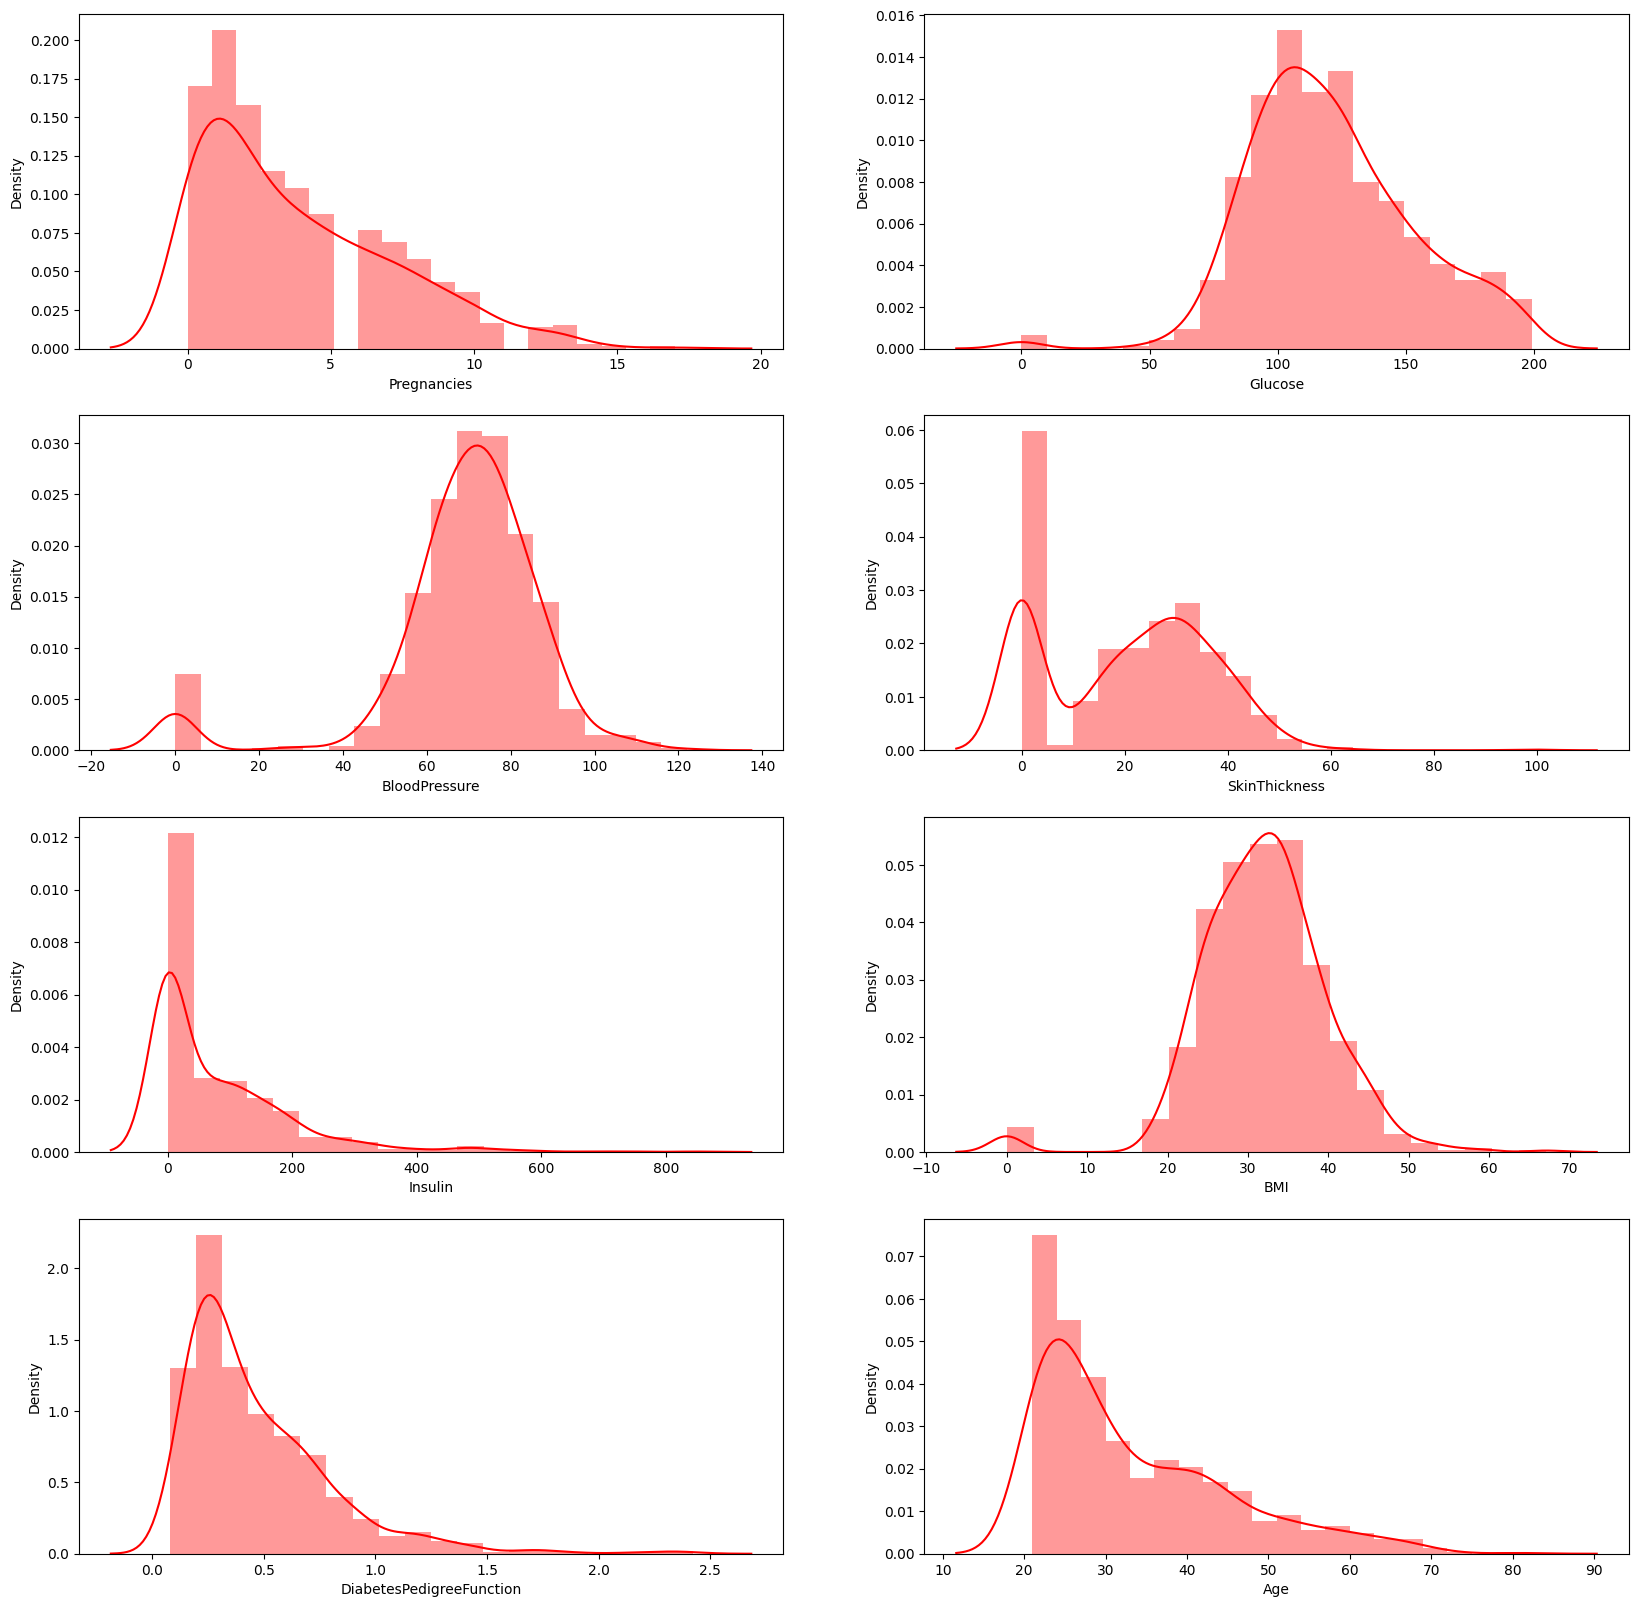

In [8]:
# density graph
fig,ax = plt.subplots(4,2, figsize=(20,20))
sns.distplot(df.Pregnancies, bins=20, ax=ax[0,0], color="red")
sns.distplot(df.Glucose, bins=20, ax=ax[0,1], color="red")
sns.distplot(df.BloodPressure, bins=20, ax=ax[1,0], color="red")
sns.distplot(df.SkinThickness, bins=20, ax=ax[1,1], color="red")
sns.distplot(df.Insulin, bins=20, ax=ax[2,0], color="red")
sns.distplot(df.BMI, bins=20, ax=ax[2,1], color="red")
sns.distplot(df.DiabetesPedigreeFunction, bins=20, ax=ax[3,0], color="red")
sns.distplot(df.Age, bins=20, ax=ax[3,1], color="red")

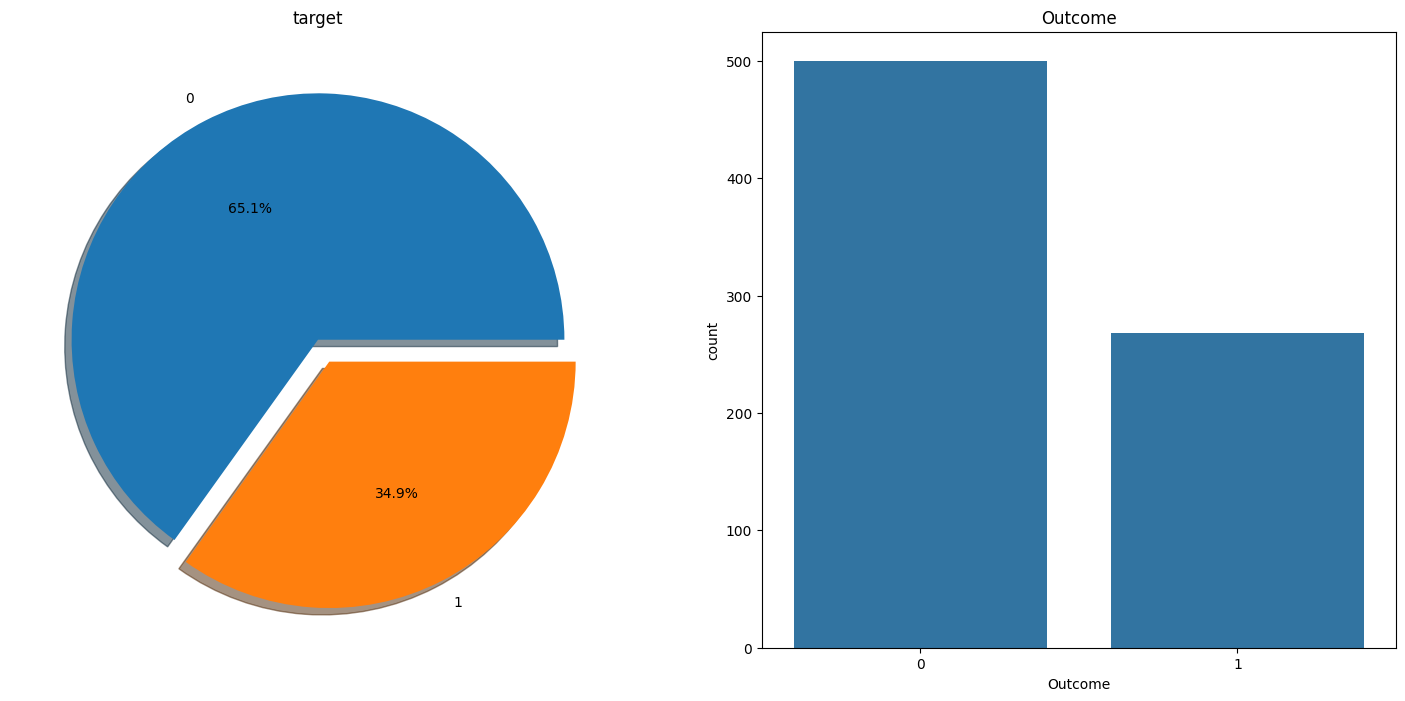

In [9]:
f,ax = plt.subplots(1,2, figsize=(18,8))
df['Outcome'].value_counts().plot.pie(explode=[0,0.1],autopct = "%1.1f%%", ax=ax[0], shadow=True)
ax[0].set_title('target')
ax[0].set_ylabel('')
sns.countplot(x='Outcome', data=df, ax=ax[1]) # Pass 'Outcome' as the 'x' argument
ax[1].set_title('Outcome')
plt.show()

> <span style='font-size:15px; font-family:Verdana;color: #254E58; border-bottom: solid 3px'><b>4.1.2 | Count null/nan values</b></span>

In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<div style="background-color:white;font-size:20px;font-family:Georgia;border-style: solid;border-color: #254E58;border-width:3px;padding:10px;margin: 1px;color:#254E58;overflow:hidden"><i>(No) missing values Found</i></div>

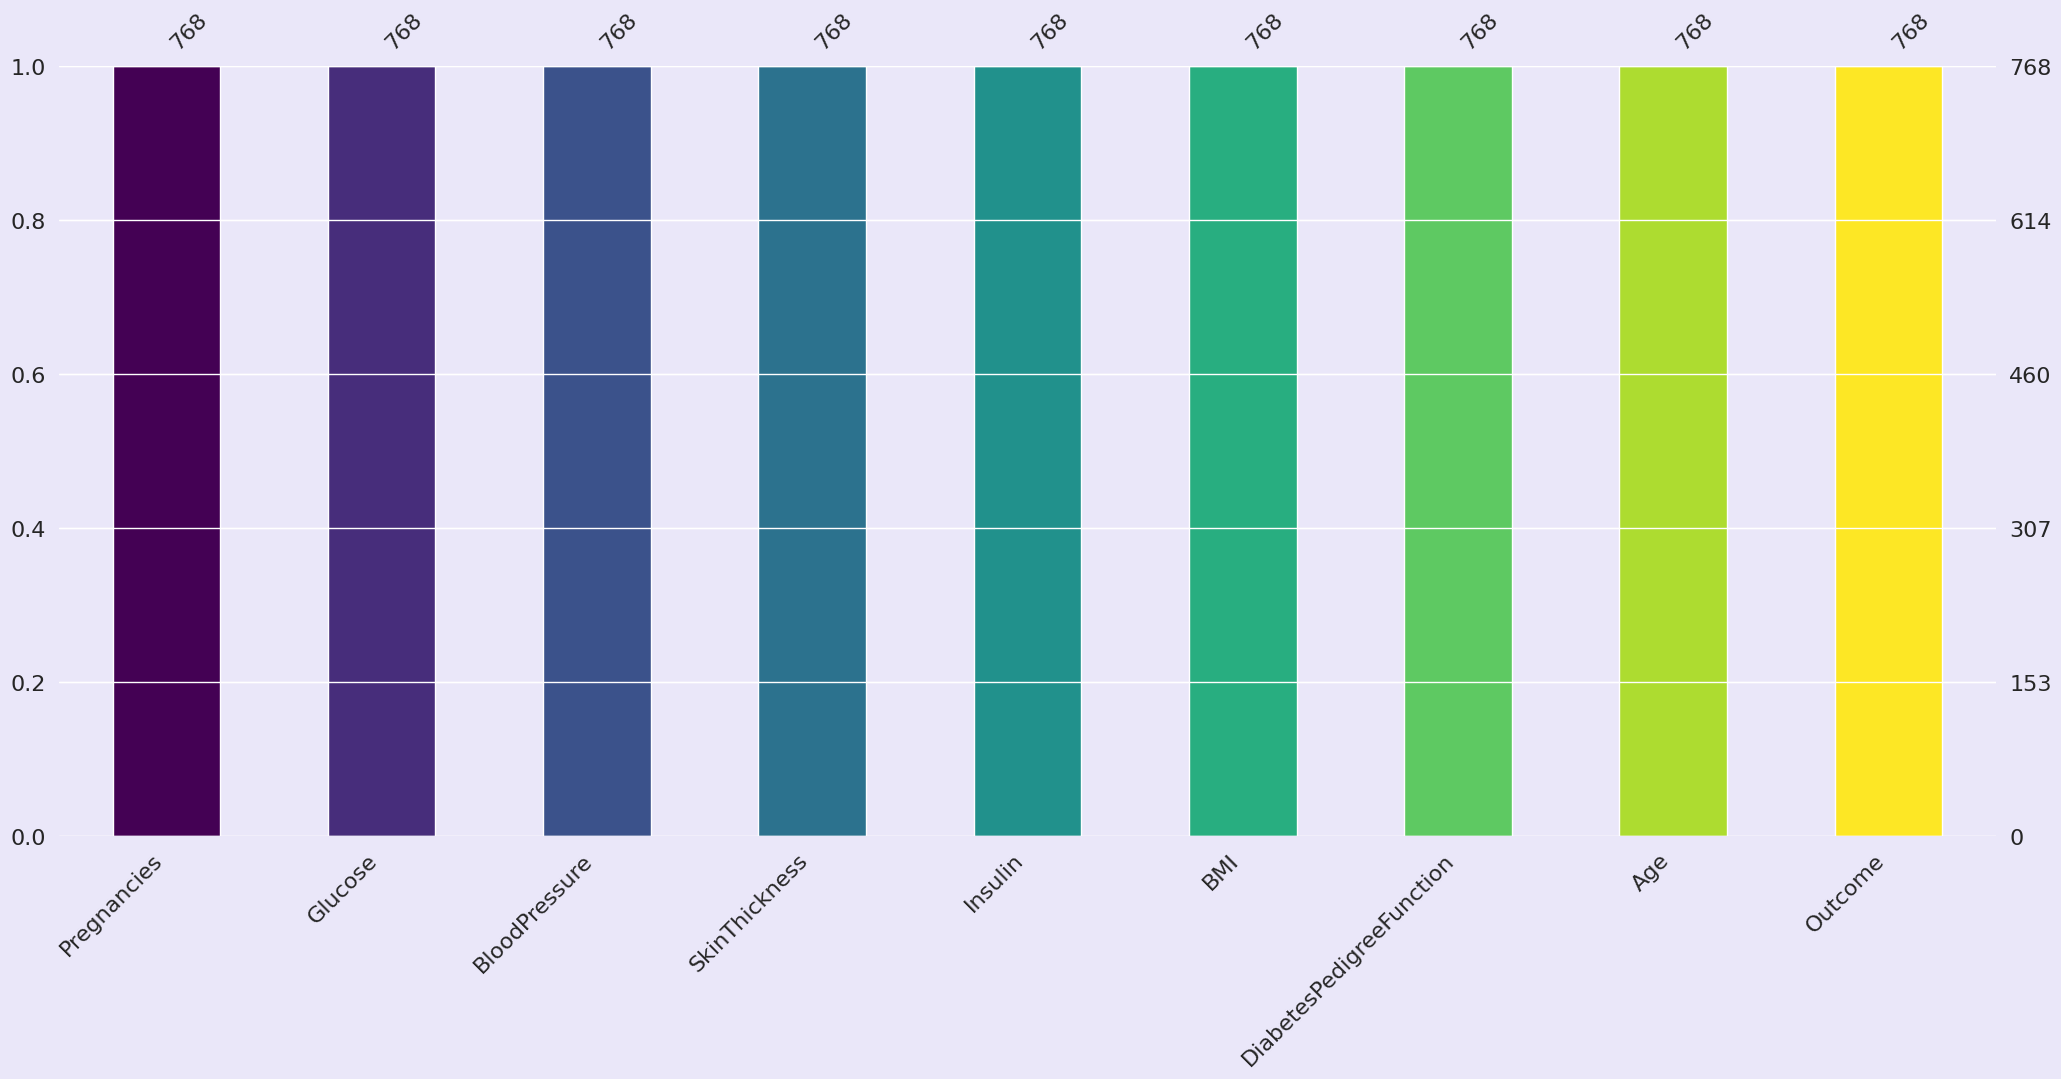

In [ ]:
import missingno as msno

num_columns = len(df.columns)
colors = plt.cm.viridis(np.linspace(0, 1, num_columns))

msno.bar(df, color=colors)
plt.show()

In [ ]:
print("\nZero Values (Potential Missing):")
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    print(f"{col}: {len(df[df[col] == 0])}")


Zero Values (Potential Missing):
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


> <span style='font-size:15px; font-family:Verdana;color: #254E58;border-bottom: solid 3px'><b>4.1.5 | Description</b></span>

In [ ]:
# Apply updated styling for df.describe() using the full theme consistently
styled_df = df.describe().style \
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#1B3A4B'),
            ('color', '#FFDA7D'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding', '10px'),
            ('border-bottom', '2px solid #FFDA7D')
        ]},
        {'selector': 'td', 'props': [
            ('padding', '10px'),
            ('border-bottom', '1px solid #FFDA7D')
        ]},
        {'selector': 'tbody tr:hover td', 'props': [
            ('background-color', '#2F5D6F')
        ]}
    ]) \
    .set_properties(**{
        'font-size': '15px',
        'background-color': '#254E58',
        'color': '#FFDA7D',
        'border-collapse': 'collapse',
        'margin': '10px',
        'border': '1px solid #FFDA7D'
    })

styled_df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<a id="4.2"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>4.2 | Visualizations</b>

> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>4.2.1 |Distributions of attributes</b></span>

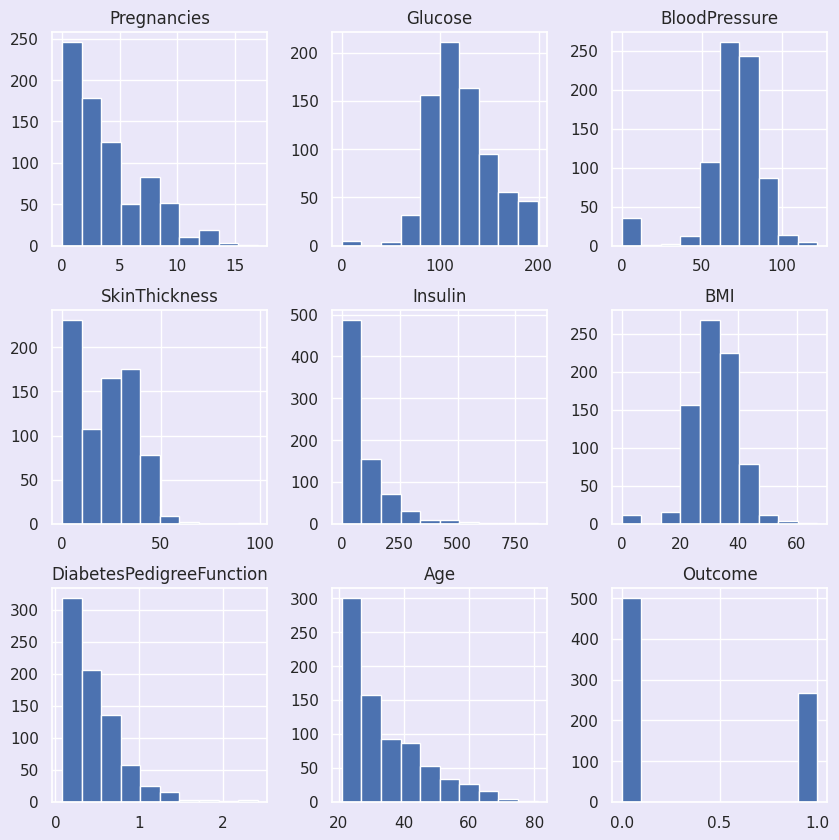

In [ ]:
df.hist(figsize = (10,10))
plt.show()

> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>4.2.2 | Boxplot</b></span>

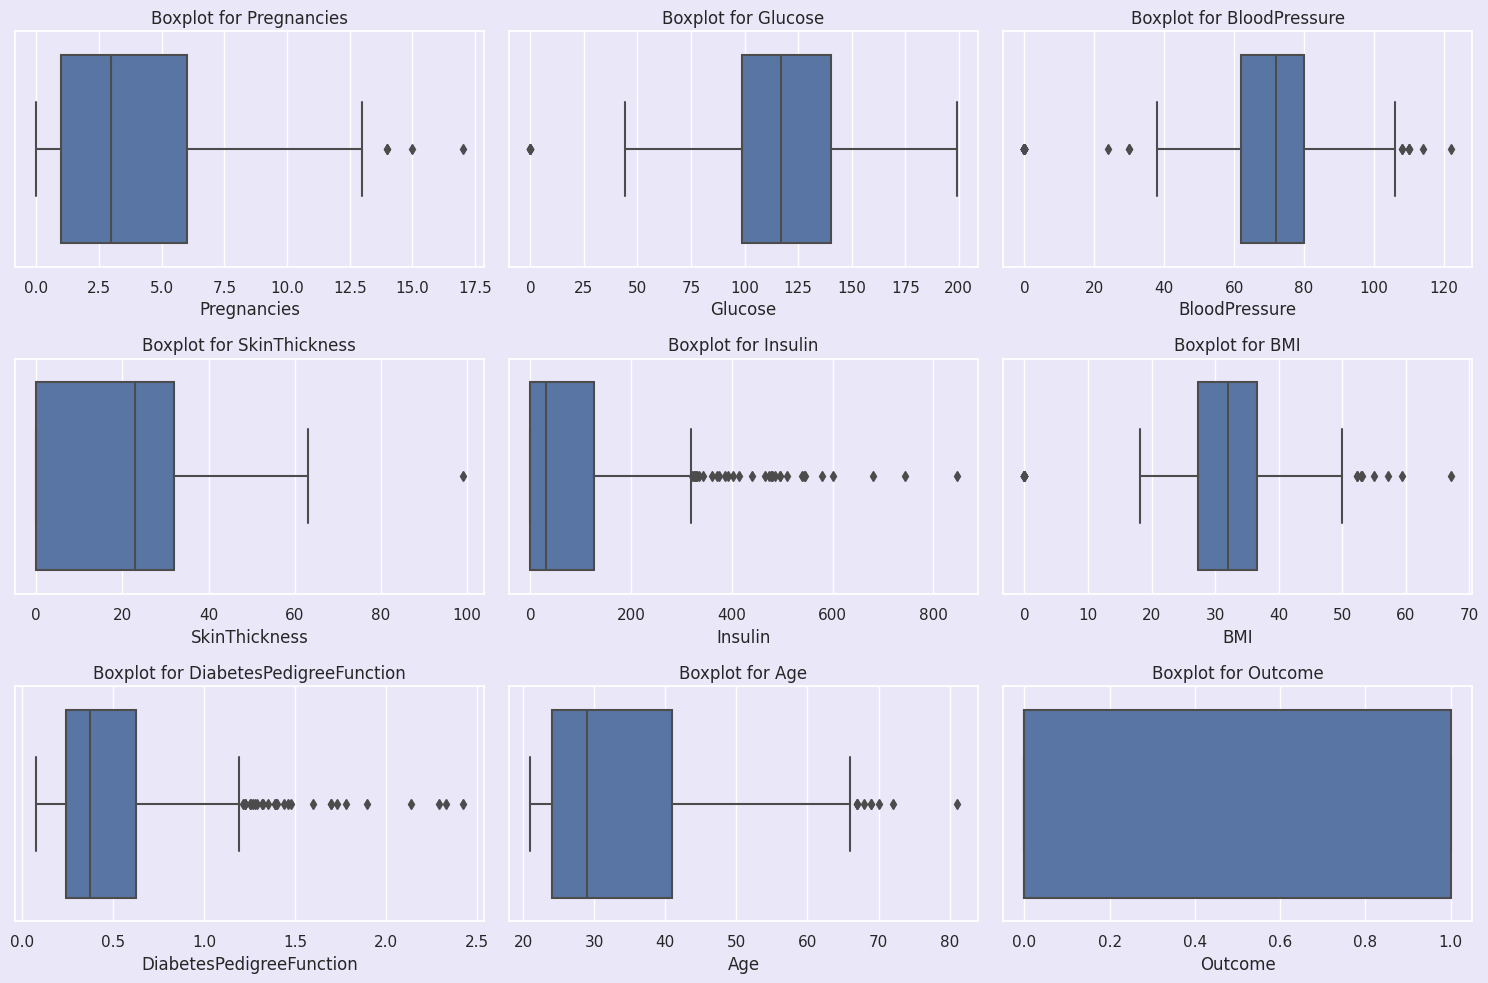

In [ ]:
num_rows, num_cols = 3, 3

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten the axes for easier iteration
axes = axes.flatten()

# Loop through numeric columns and create boxplots
for i, column in enumerate(df.columns):
    sns.boxplot(data=df, x=column, ax=axes[i])
    axes[i].set_title(f'Boxplot for {column}')

# Remove any remaining empty subplots
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>4.2.3 | Pairplot of attributes</b></span>

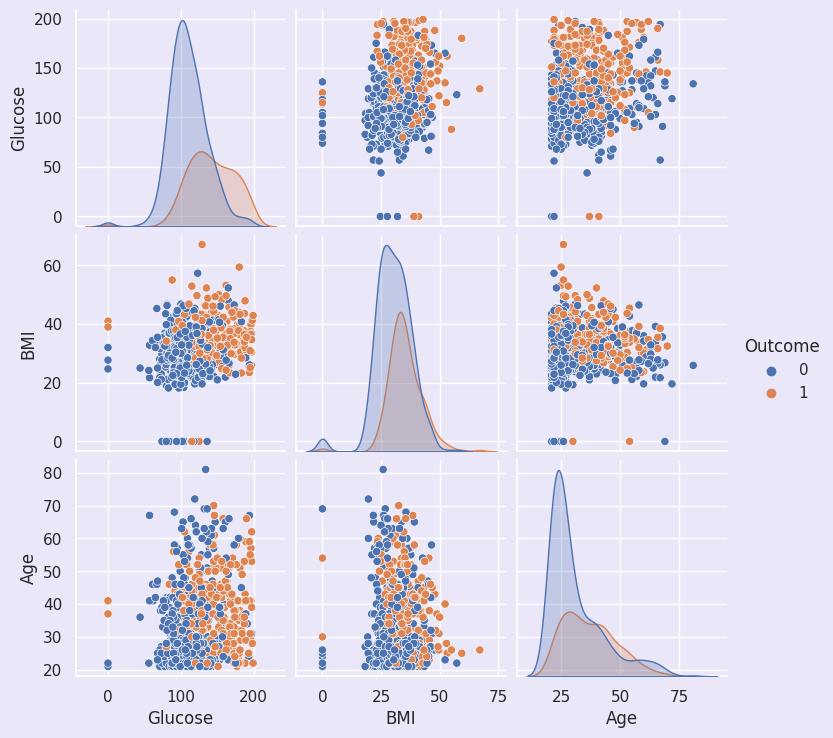

In [ ]:
sns.pairplot(data=df[['Glucose', 'BMI', 'Age', 'Outcome']], hue='Outcome')
plt.show()


> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>4.2.4 | Age and Outcome</b></span>

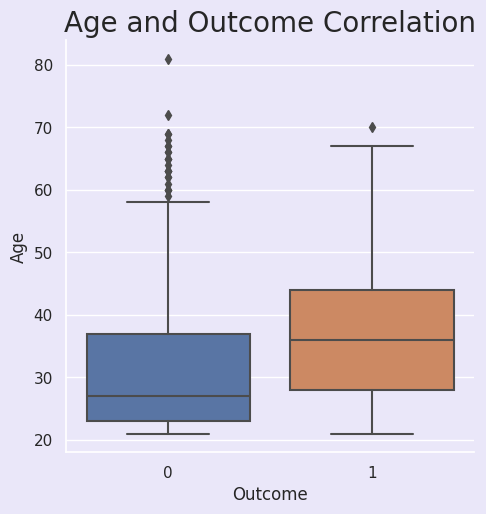

In [ ]:
sns.set(rc={"axes.facecolor":"#EAE7F9","figure.facecolor":"#EAE7F9"})
p=sns.catplot(x="Outcome",y="Age", data=df, kind='box')
plt.title("Age and Outcome Correlation", size=20, y=1.0);

> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>4.2.5 | Glucose and Outcome Correlation</b></span>

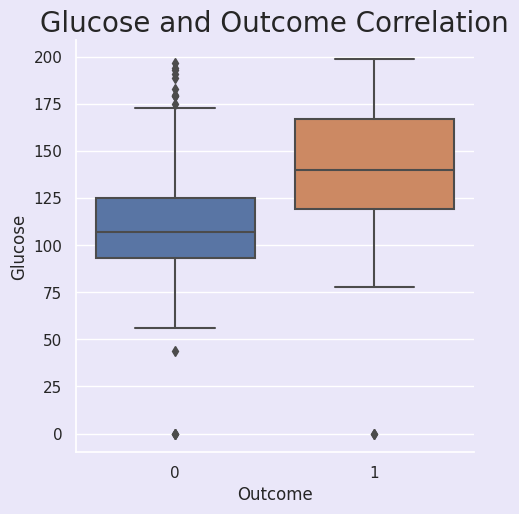

In [ ]:
sns.set(rc={"axes.facecolor":"#EAE7F9","figure.facecolor":"#EAE7F9"})
p=sns.catplot(x="Outcome",y="Glucose", data=df, kind='box')
plt.title("Glucose and Outcome Correlation", size=20, y=1.0);

> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>4.2.6 | Correlation between attributes</b></span>

<Axes: >

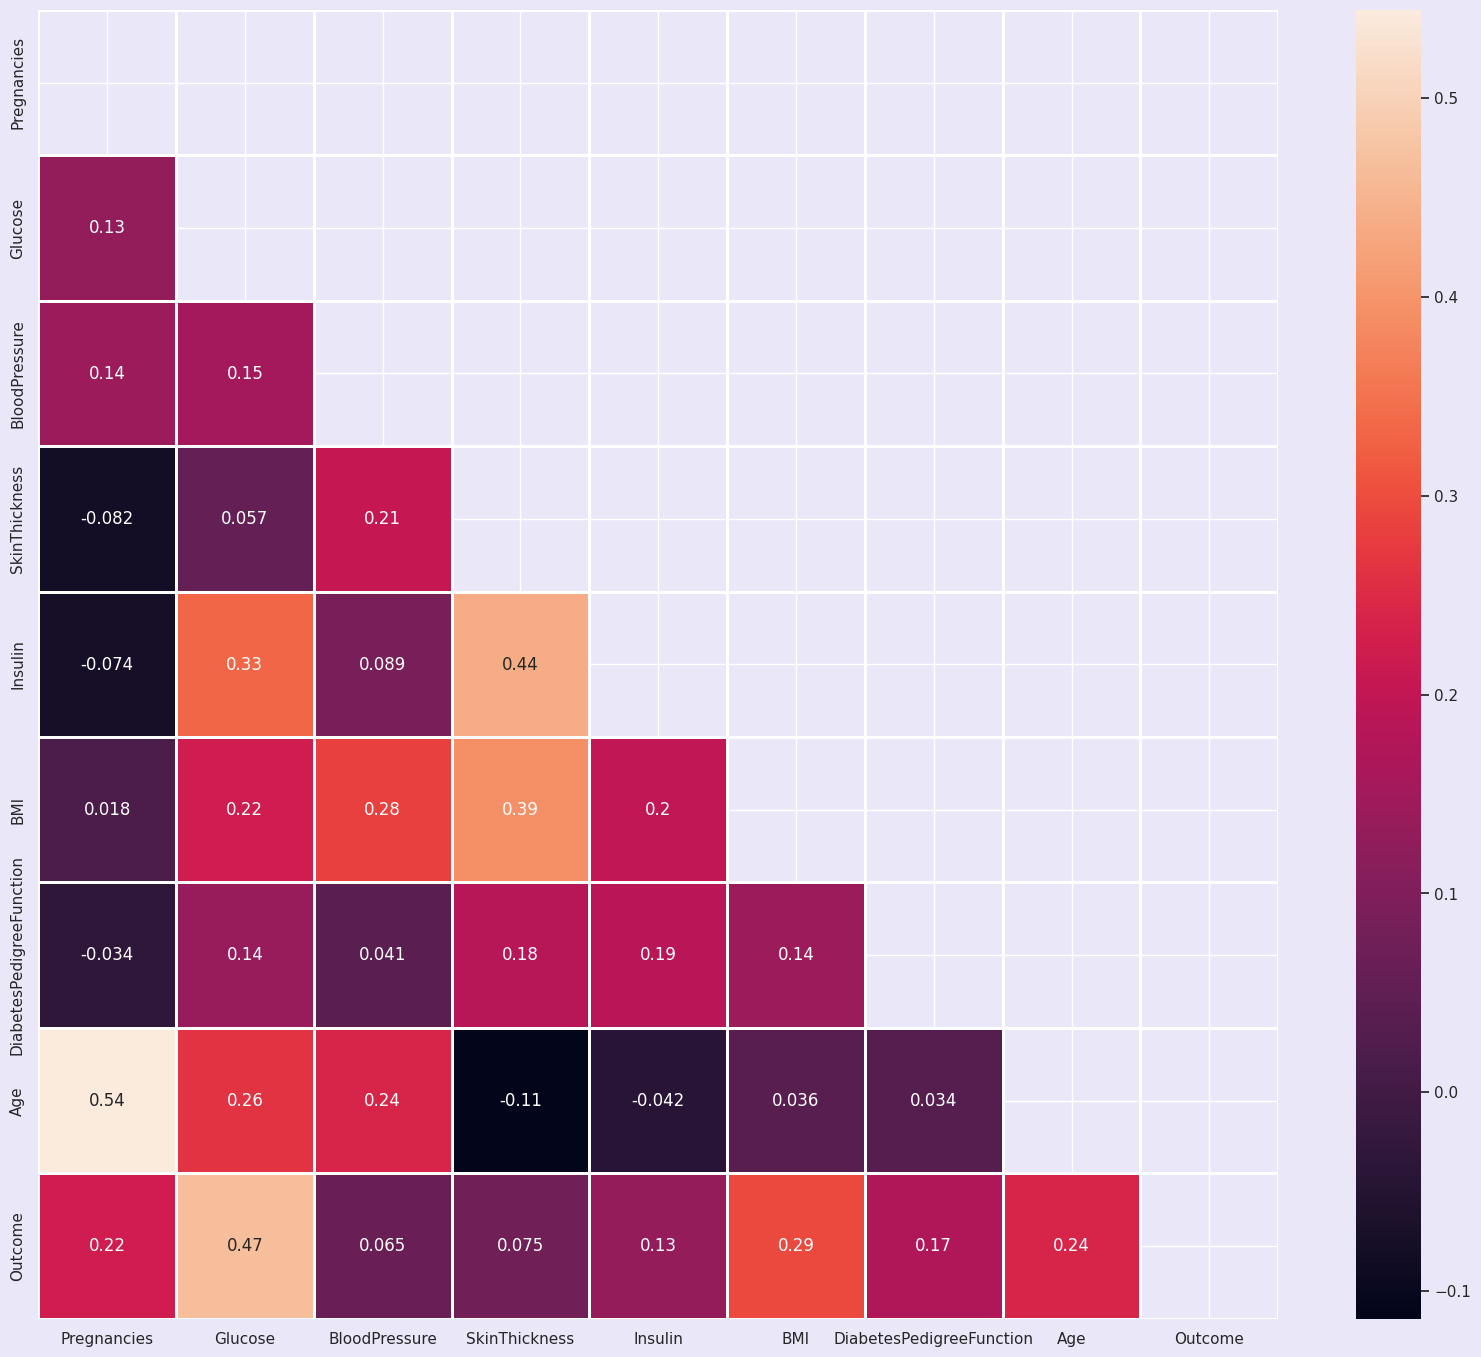

In [ ]:
plt.figure(figsize=(20, 17))
matrix = np.triu(df.corr())
sns.heatmap(df.corr(), annot=True, linewidth=.8, mask=matrix, cmap="rocket")

<Axes: >

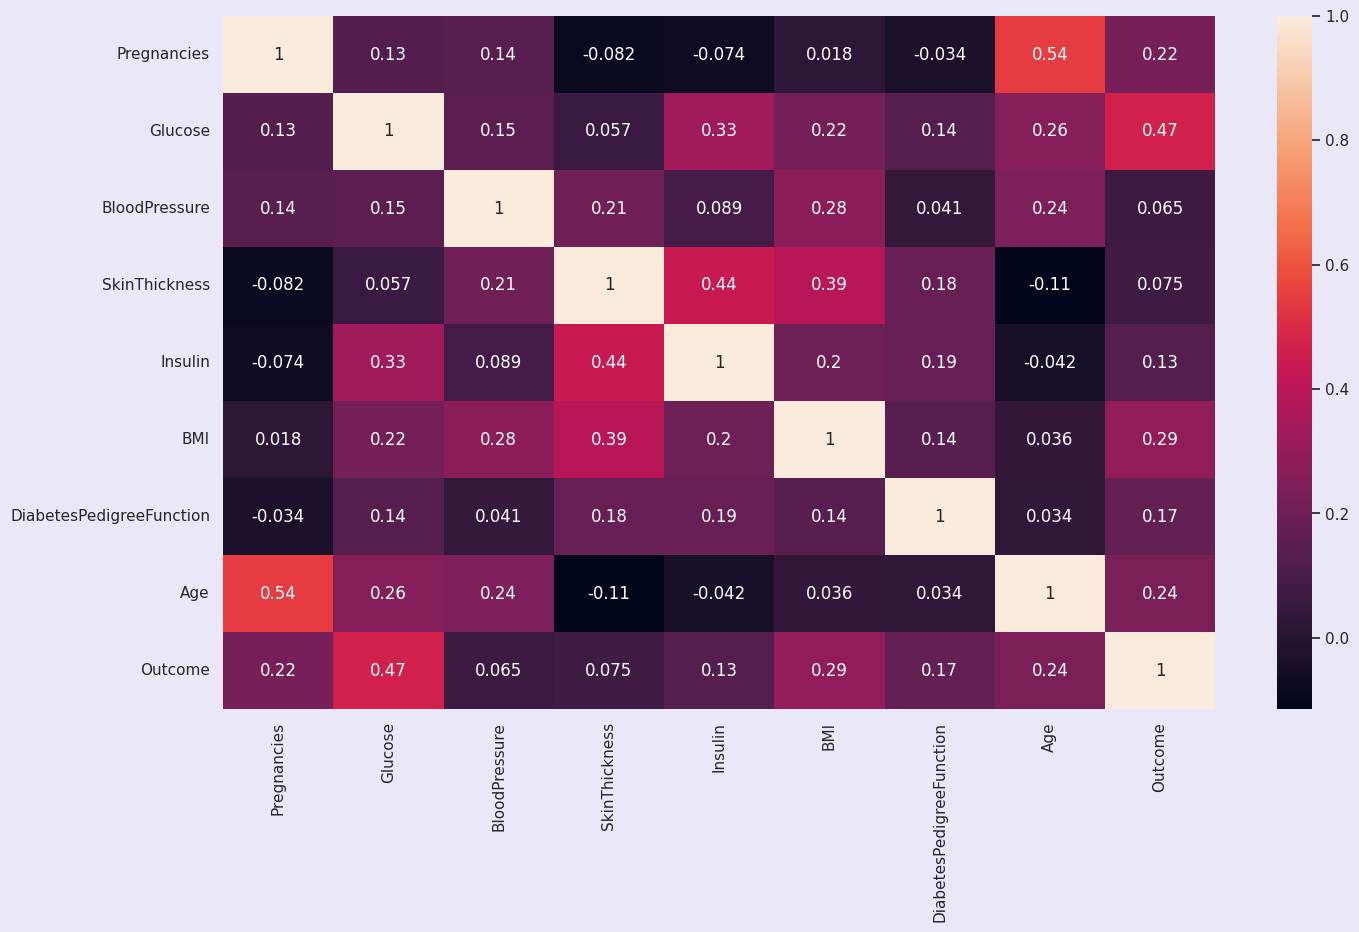

In [ ]:
plt.figure(figsize=(16,9))
sns.heatmap(df.corr(), annot=True)

In [ ]:
hig_corr = df.corr()
hig_corr_features = hig_corr.index[abs(hig_corr["Outcome"]) >= 0.2]
hig_corr_features

Index(['Pregnancies', 'Glucose', 'BMI', 'Age', 'Outcome'], dtype='object')

In [ ]:
#Standard Deviation
df.var()

Pregnancies                    11.354056
Glucose                      1022.248314
BloodPressure                 374.647271
SkinThickness                 254.473245
Insulin                     13281.180078
BMI                            62.159984
DiabetesPedigreeFunction        0.109779
Age                           138.303046
Outcome                         0.227483
dtype: float64

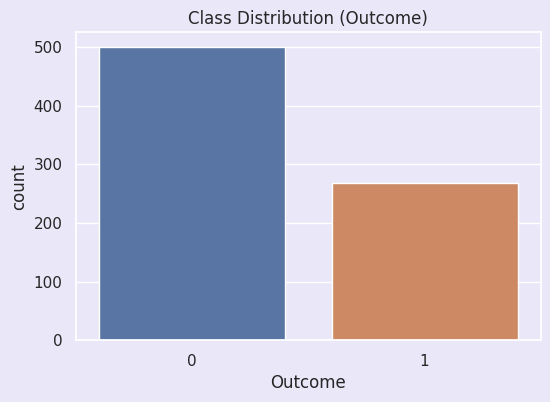

In [ ]:
# Class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Class Distribution (Outcome)')
plt.show()

<a id="5"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">5 | Data Preprocessing</div>

This section prepares the Pima Indians Diabetes Dataset for model training to ensure robust comparisons of single and hybrid models. The steps, executed in order, are:

1. **Handle Outliers**: Extreme values in `Insulin` and `DiabetesPedigreeFunction` are capped using the Interquartile Range (IQR) method (values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are replaced with respective limits). This reduces the impact of outliers on skewed features, ensuring stable model training.
2. **Replace Zero Values**: Zeros in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are invalid (e.g., 0 `Glucose` is impossible) and represent missing data. These are replaced with median values, computed after outlier handling, for robustness to skewness (e.g., `Insulin`).
3. **Train-Test Split**: Data is split into 80% training and 20% testing sets for consistent evaluation.
4. **Feature Scaling**: Features are standardized using `StandardScaler` to ensure equal weighting for models like SVM and ANN.

Handling outliers before zero imputation ensures medians are calculated on a cleaner dataset, avoiding bias from extreme values or invalid zeros. The processed data supports fair comparisons of ANN, SVM, Decision Tree, SVM + DT + RF, and Fuzzy + ANN in subsequent sections.

> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>Step 1: Handle outliers in Insulin and DiabetesPedigreeFunction </b></span>

In [10]:
df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']] = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']].replace(0, np.nan)

In [11]:
df.isnull().sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,NaN,137.0,40.0,35.0,168.0,43.1,2.288,33,1


<Axes: >

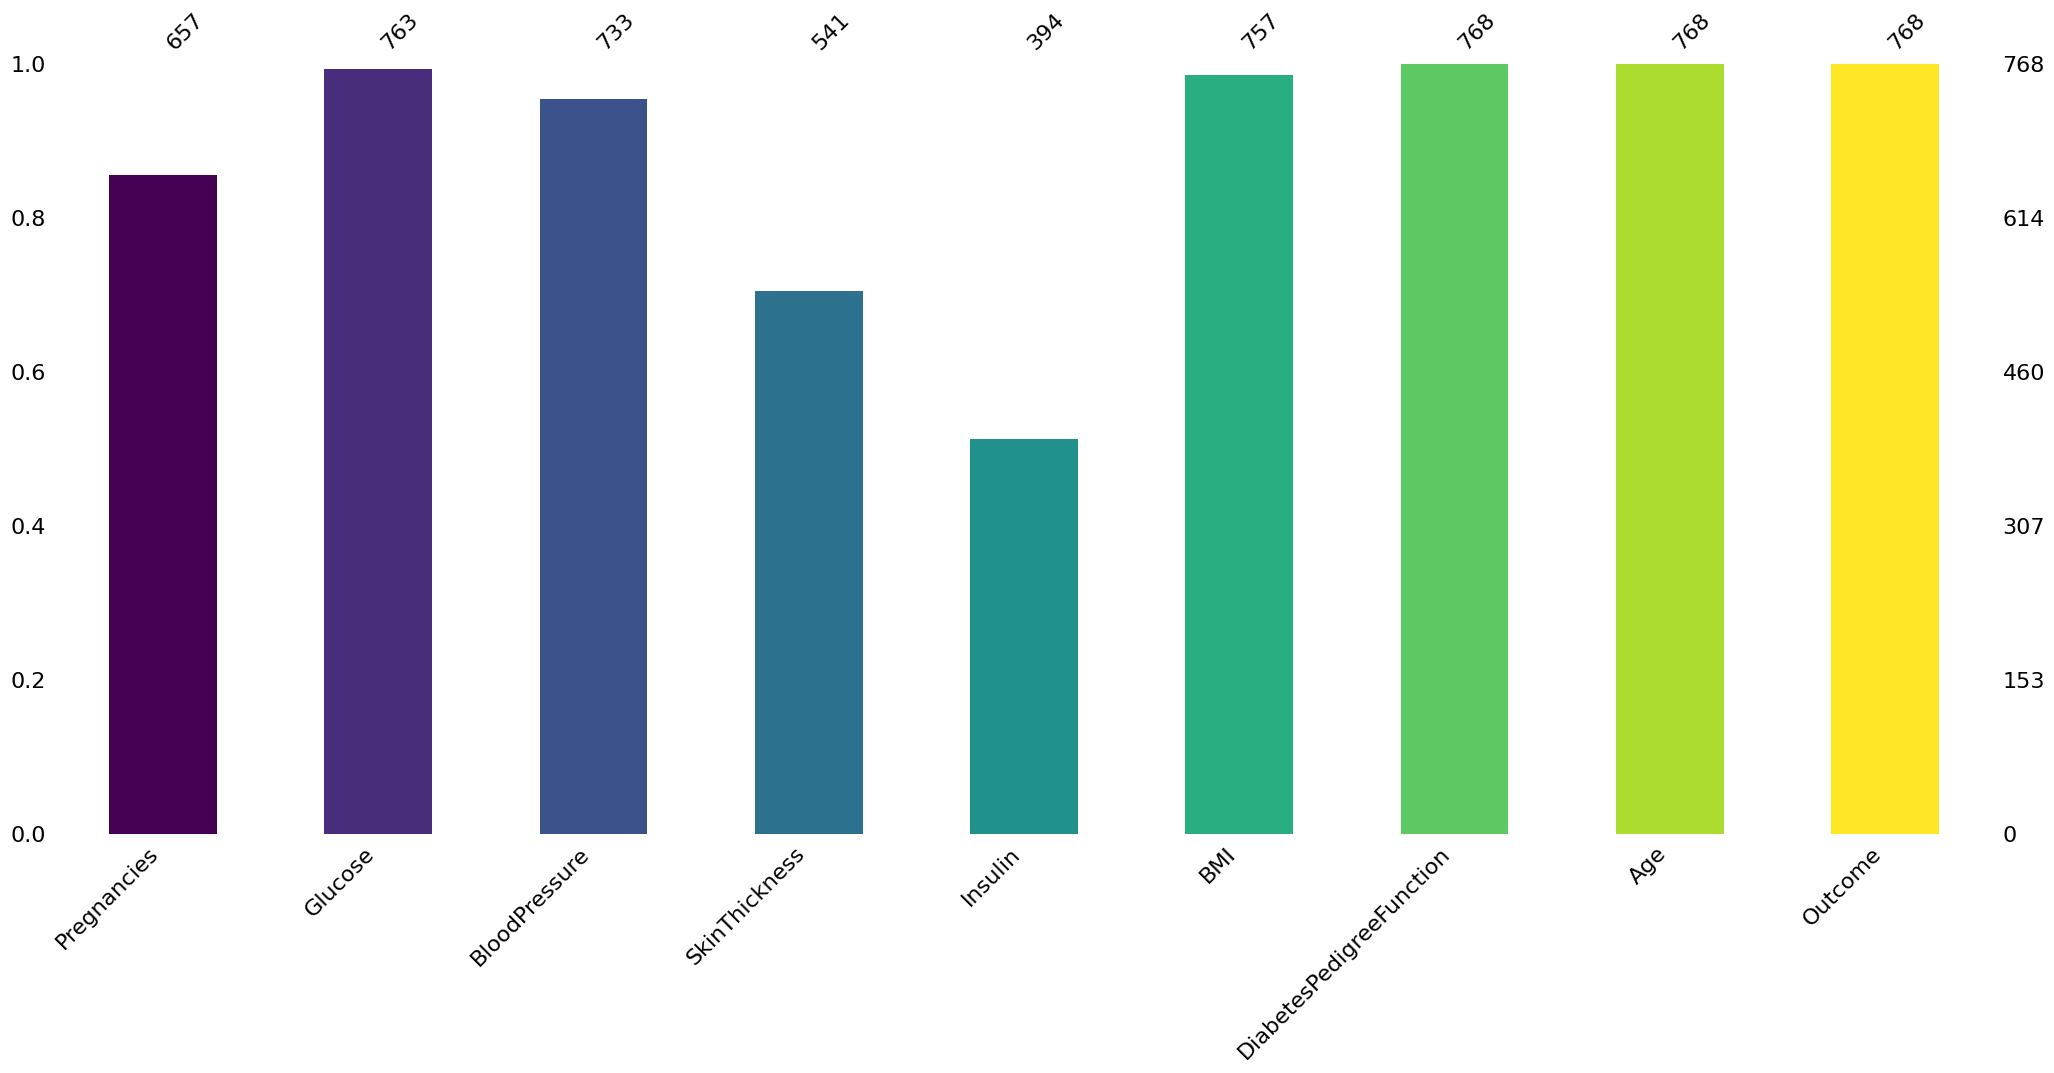

In [17]:
import missingno as msno
num_columns = len(df.columns)
colors = plt.cm.viridis(np.linspace(0, 1, num_columns))
msno.bar(df, color=colors)

In [18]:
#median
def median_target(var):
    temp = df[df[var].notnull()]
    temp = temp[[var, 'Outcome']].groupby(['Outcome'])[[var]].median().reset_index()
    return temp

In [19]:
columns = df.columns
columns = columns.drop("Outcome")
for i in columns:
    median_target(i)
    df.loc[(df['Outcome'] == 0 ) & (df[i].isnull()), i] = median_target(i)[i][0]
    df.loc[(df['Outcome'] == 1 ) & (df[i].isnull()), i] = median_target(i)[i][1]

In [20]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,5.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [21]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


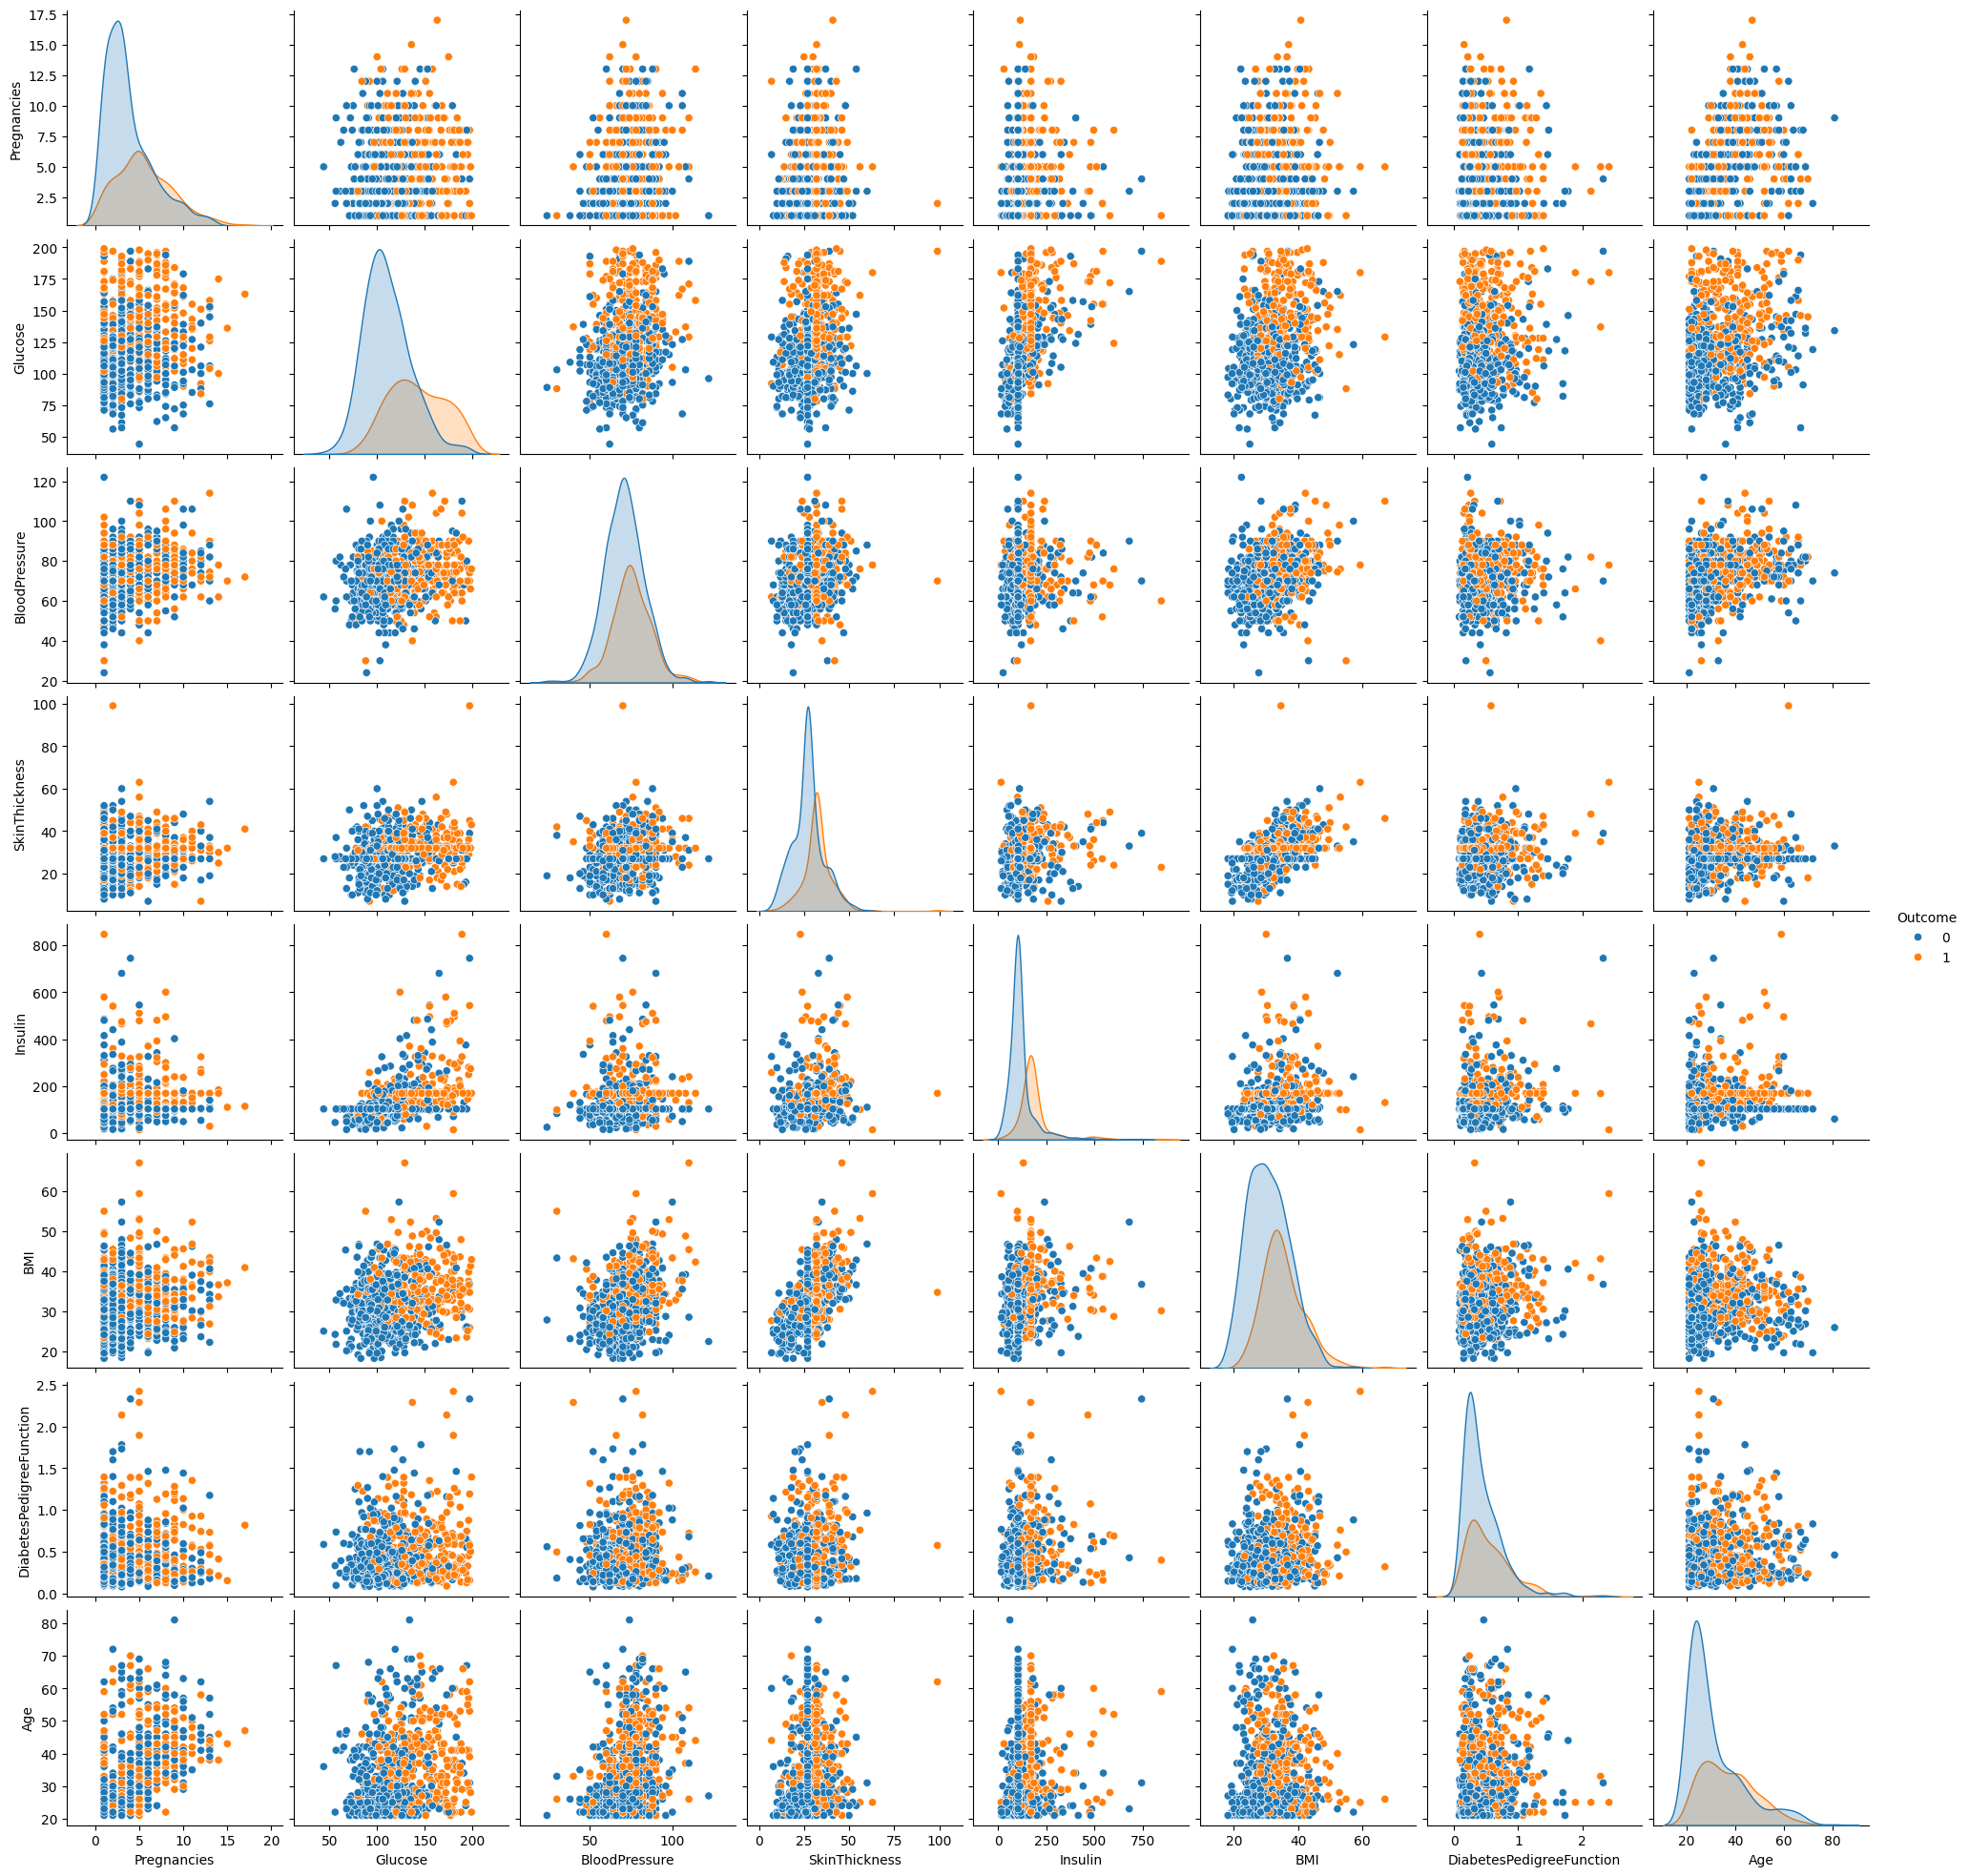

In [22]:
# pair plot
p = sns.pairplot(df, hue="Outcome")

In [23]:
# Outlier Detection
# IQR+Q1
# 50%
# 24.65->25%+50%
# 24.65->25%
for feature in df:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    if df[(df[feature]>upper)].any(axis=None):
        print(feature, "yes")
    else:
        print(feature, "no")

Pregnancies yes
Glucose no
BloodPressure yes
SkinThickness yes
Insulin yes
BMI yes
DiabetesPedigreeFunction yes
Age yes
Outcome no


<Axes: xlabel='Insulin'>

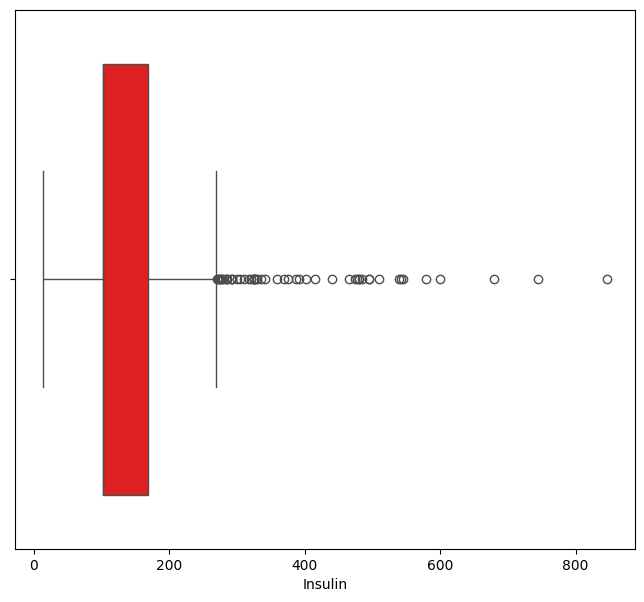

In [24]:
plt.figure(figsize=(8,7))
sns.boxplot(x= df["Insulin"], color="red")

In [25]:
Q1 = df.Insulin.quantile(0.25)
Q3 = df.Insulin.quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df.loc[df['Insulin']>upper, "Insulin"] = upper

<Axes: xlabel='Insulin'>

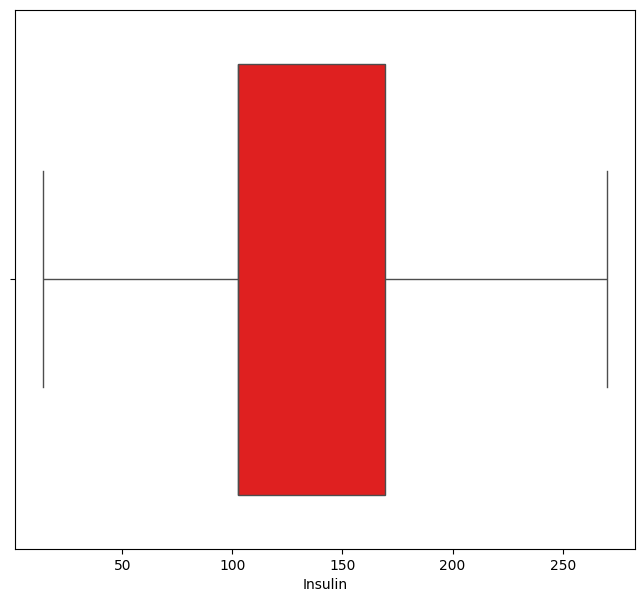

In [26]:
plt.figure(figsize=(8,7))
sns.boxplot(x= df["Insulin"], color="red")

In [27]:
# local outlier factor
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=10)
lof.fit_predict(df)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1

In [28]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,5.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


<Axes: xlabel='Pregnancies'>

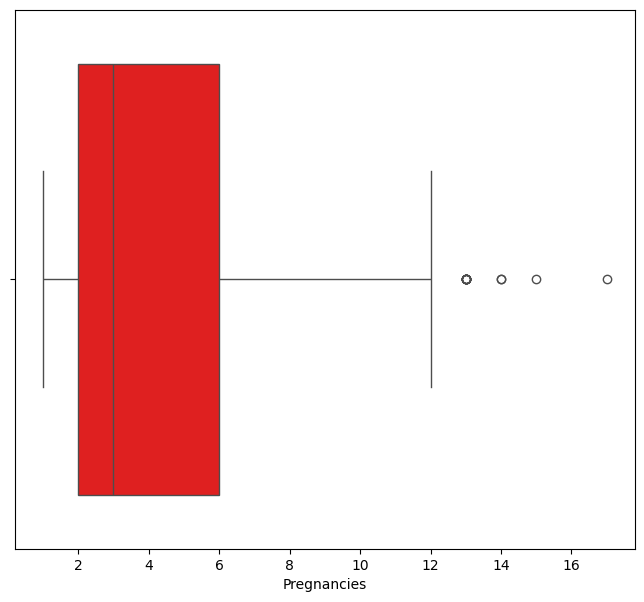

In [29]:
plt.figure(figsize=(8,7))
sns.boxplot(x= df["Pregnancies"], color="red")

In [30]:
df_scores = lof.negative_outlier_factor_
np.sort(df_scores)[0:20]

array([-3.06509976, -2.38250393, -2.15557018, -2.11501347, -2.08356175,
       -1.95386655, -1.83559384, -1.74974237, -1.7330214 , -1.71017168,
       -1.70215105, -1.68722889, -1.64294601, -1.64180205, -1.61181746,
       -1.61067772, -1.60925053, -1.60214364, -1.59998552, -1.58761193])

In [38]:
# Recalculate lof and outlier after modifying df
lof = LocalOutlierFactor(n_neighbors=10)
lof.fit_predict(df)
df_scores = lof.negative_outlier_factor_
threshold = np.sort(df_scores)[7]
outlier = df_scores > threshold

# Now, apply the boolean indexing
df = df[outlier]

In [39]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,5.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [40]:

df.shape

(752, 9)

<Axes: xlabel='Pregnancies'>

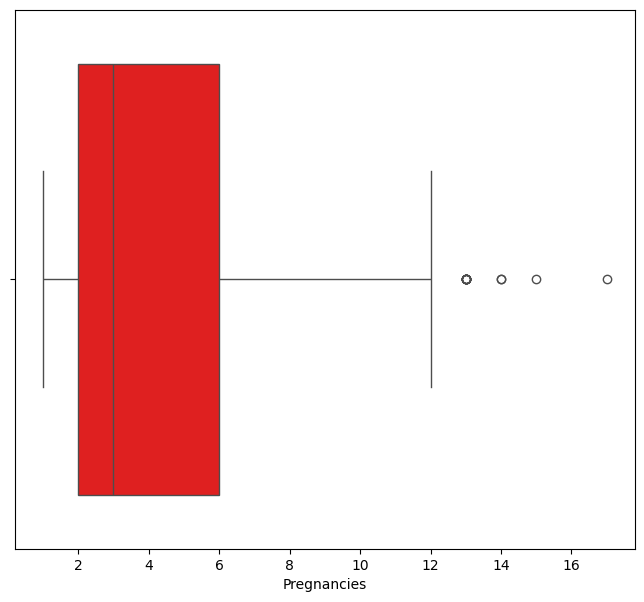

In [42]:
plt.figure(figsize=(8,7))
sns.boxplot(x= df["Pregnancies"], color="red")


In [43]:
# Feature Enginnering
NewBMI = pd.Series(["Underweight","Normal", "Overweight","Obesity 1", "Obesity 2", "Obesity 3"], dtype = "category")
NewBMI

,0
0,Underweight
1,Normal
2,Overweight
3,Obesity 1
4,Obesity 2
5,Obesity 3


In [44]:
df['NewBMI'] = NewBMI
df.loc[df["BMI"]<18.5, "NewBMI"] = NewBMI[0]
df.loc[(df["BMI"]>18.5) & df["BMI"]<=24.9, "NewBMI"] = NewBMI[1]
df.loc[(df["BMI"]>24.9) & df["BMI"]<=29.9, "NewBMI"] = NewBMI[2]
df.loc[(df["BMI"]>29.9) & df["BMI"]<=34.9, "NewBMI"] = NewBMI[3]
df.loc[(df["BMI"]>34.9) & df["BMI"]<=39.9, "NewBMI"] = NewBMI[4]
df.loc[df["BMI"]>39.9, "NewBMI"] = NewBMI[5]

In [45]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50,1,Obesity 2
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31,0,Obesity 2
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32,1,Obesity 2
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Obesity 2
4,5.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obesity 3


In [46]:
# if insulin>=16 & insuline<=166->normal
def set_insuline(row):
    if row["Insulin"]>=16 and row["Insulin"]<=166:
        return "Normal"
    else:
        return "Abnormal"

In [47]:
df = df.assign(NewInsulinScore=df.apply(set_insuline, axis=1))

In [48]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50,1,Obesity 2,Abnormal
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31,0,Obesity 2,Normal
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32,1,Obesity 2,Abnormal
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Obesity 2,Normal
4,5.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obesity 3,Abnormal


In [49]:
# Some intervals were determined according to the glucose variable and these were assigned categorical variables.
NewGlucose = pd.Series(["Low", "Normal", "Overweight", "Secret", "High"], dtype = "category")
df["NewGlucose"] = NewGlucose
df.loc[df["Glucose"] <= 70, "NewGlucose"] = NewGlucose[0]
df.loc[(df["Glucose"] > 70) & (df["Glucose"] <= 99), "NewGlucose"] = NewGlucose[1]
df.loc[(df["Glucose"] > 99) & (df["Glucose"] <= 126), "NewGlucose"] = NewGlucose[2]
df.loc[df["Glucose"] > 126 ,"NewGlucose"] = NewGlucose[3]

In [50]:
# One hot encoding
df = pd.get_dummies(df, columns = ["NewBMI", "NewInsulinScore", "NewGlucose"], drop_first=True)

In [51]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret'],
      dtype='object')

In [52]:
categorical_df = df[['NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret']]

In [53]:
categorical_df.head()

,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,False,True,False,False,False,False,False,False,False,True
1,False,True,False,False,False,True,False,True,False,False
2,False,True,False,False,False,False,False,False,False,True
3,False,True,False,False,False,True,False,True,False,False
4,False,False,True,False,False,False,False,False,False,True


In [54]:
y=df['Outcome']
X=df.drop(['Outcome','NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret'], axis=1)

In [55]:
cols = X.columns
index = X.index

In [56]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21
4,5.0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [57]:
from sklearn.preprocessing import RobustScaler
transformer = RobustScaler().fit(X)
X=transformer.transform(X)
X=pd.DataFrame(X, columns = cols, index = index)

In [58]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.75,0.770186,0.000,1.000000,0.981343,0.162465,0.685639,1.235294
1,-0.50,-0.795031,-0.375,0.142857,-0.018657,-0.621849,-0.045003,0.117647
2,1.25,1.639752,-0.500,0.571429,0.981343,-0.991597,0.804765,0.176471
3,-0.50,-0.695652,-0.375,-0.714286,-0.145522,-0.453782,-0.532098,-0.470588
4,0.50,0.496894,-2.000,1.000000,0.958955,1.226891,5.082727,0.235294


In [59]:
X = pd.concat([X, categorical_df], axis=1)

In [60]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,0.75,0.770186,0.000,1.000000,0.981343,0.162465,0.685639,1.235294,False,True,False,False,False,False,False,False,False,True
1,-0.50,-0.795031,-0.375,0.142857,-0.018657,-0.621849,-0.045003,0.117647,False,True,False,False,False,True,False,True,False,False
2,1.25,1.639752,-0.500,0.571429,0.981343,-0.991597,0.804765,0.176471,False,True,False,False,False,False,False,False,False,True
3,-0.50,-0.695652,-0.375,-0.714286,-0.145522,-0.453782,-0.532098,-0.470588,False,True,False,False,False,True,False,True,False,False
4,0.50,0.496894,-2.000,1.000000,0.958955,1.226891,5.082727,0.235294,False,False,True,False,False,False,False,False,False,True


> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>Step 4: Train-test split</b></span>

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20,random_state=0)

> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>Step 5: Scale features
</b></span>

In [68]:
scaler =StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [69]:
print("Preprocessing complete. Train shape:", X_train.shape, "Test shape:", X_test.shape)

Preprocessing complete. Train shape: (601, 18) Test shape: (151, 18)


> <span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>Evaluation function</b></span>

In [70]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, is_ann=False):
    results = []

    for X, y_true, dataset_label in [(X_train, y_train, "Training"), (X_test, y_test, "Validation")]:
        # Predict
        if is_ann:
            y_pred = (model.predict(X) > 0.5).astype("int32").flatten()
            y_proba = model.predict(X).flatten()
        else:
            y_pred = model.predict(X)
            y_proba = model.predict_proba(X)[:, 1]

        # Classification report
        report = classification_report(y_true, y_pred, output_dict=True, digits=4)
        print(f"\n📊 Classification Report - {model_name} ({dataset_label})")
        print(classification_report(y_true, y_pred, digits=4))

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix - {model_name} ({dataset_label})')
        plt.grid(False)
        plt.show()

        # Collect metrics
        results.append({
            'Model': model_name,
            'Dataset': dataset_label,
            'Accuracy': report['accuracy'],
            'Precision': report['1']['precision'],
            'Recall': report['1']['recall'],
            'F1-Score': report['1']['f1-score'],
            'AUC-ROC': roc_auc_score(y_true, y_proba)
        })

    return pd.DataFrame(results)

print("Preprocessing and evaluation function ready.")

Preprocessing and evaluation function ready.


<a id="6"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">6 | Single Models (Basedline)</div>

<a id="6.1"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>6.1 |Decision Tree</b>


📊 Classification Report - Decision Tree (Training)
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       394
           1     1.0000    1.0000    1.0000       207

    accuracy                         1.0000       601
   macro avg     1.0000    1.0000    1.0000       601
weighted avg     1.0000    1.0000    1.0000       601



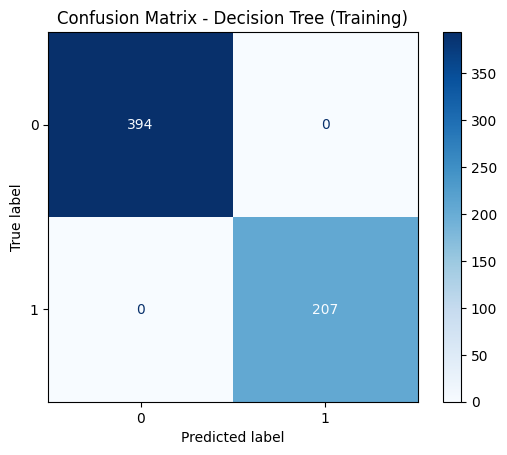


📊 Classification Report - Decision Tree (Validation)
              precision    recall  f1-score   support

           0     0.8804    0.8526    0.8663        95
           1     0.7627    0.8036    0.7826        56

    accuracy                         0.8344       151
   macro avg     0.8216    0.8281    0.8245       151
weighted avg     0.8368    0.8344    0.8353       151



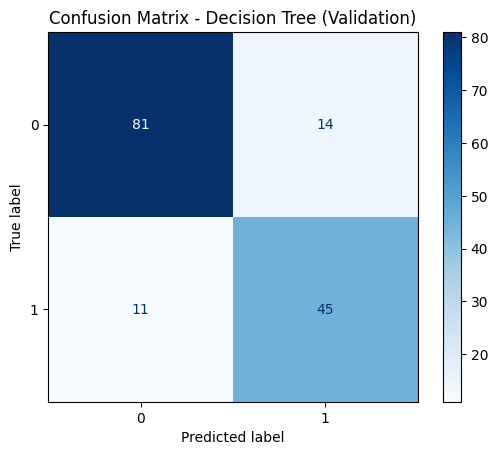


Decision Tree Results:
           Model     Dataset  Accuracy  Precision    Recall  F1-Score  \
0  Decision Tree    Training  1.000000   1.000000  1.000000  1.000000   
1  Decision Tree  Validation  0.834437   0.762712  0.803571  0.782609   

    AUC-ROC  
0  1.000000  
1  0.828102  


In [71]:
# Train Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_scaled, y_train)

# Evaluate
dt_results = evaluate_model(dtree, "Decision Tree", X_train_scaled, X_test_scaled, y_train, y_test, is_ann=False)

# Display results
print("\nDecision Tree Results:")
print(dt_results)


<div style="background-color:white;font-size:15px;font-family:Georgia;border-style: solid;border-color: #254E58;border-width:3px;padding:10px;margin: 1px;color:#254E58;overflow:hidden">
  <b>🌲 Decision Tree Classifier</b><br>
  - Training Accuracy: 100% ❗<br>
  - Validation Accuracy: ~72%<br>
  <b>The model perfectly fits the training data, clearly indicating overfitting. While validation recall (69.1%) is higher than SVM, generalization suffers, resulting in moderate F1 performance and reduced robustness.</b>
</div>


<a id="6.2"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>6.2 |Support Vector Machine (SVM)</b>


📊 Classification Report - SVM (Training)
              precision    recall  f1-score   support

           0     0.9071    0.9416    0.9240       394
           1     0.8802    0.8164    0.8471       207

    accuracy                         0.8985       601
   macro avg     0.8936    0.8790    0.8856       601
weighted avg     0.8978    0.8985    0.8975       601



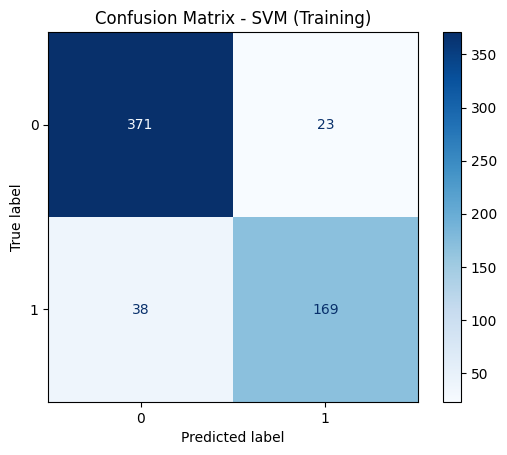


📊 Classification Report - SVM (Validation)
              precision    recall  f1-score   support

           0     0.8947    0.8947    0.8947        95
           1     0.8214    0.8214    0.8214        56

    accuracy                         0.8675       151
   macro avg     0.8581    0.8581    0.8581       151
weighted avg     0.8675    0.8675    0.8675       151



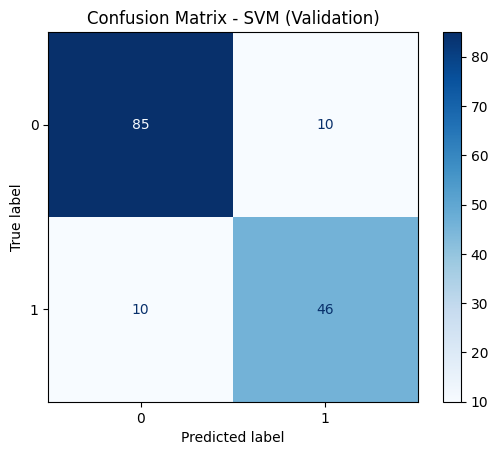


SVM Results:
  Model     Dataset  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0   SVM    Training  0.898502   0.880208  0.816425  0.847118  0.954903
1   SVM  Validation  0.867550   0.821429  0.821429  0.821429  0.888534


In [72]:
# Train SVM
svm = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)

# Evaluate
svm_results = evaluate_model(svm, "SVM", X_train_scaled, X_test_scaled, y_train, y_test, is_ann=False)

# Display results
print("\nSVM Results:")
print(svm_results)

<div style="background-color:white;font-size:15px;font-family:Georgia;border-style: solid;border-color: #254E58;border-width:3px;padding:10px;margin: 1px;color:#254E58;overflow:hidden">
  <b>🧠 Support Vector Machine (SVM)</b><br>
  - Training Accuracy: ~83%<br>
  - Validation Accuracy: ~73%<br>
  <b>SVM demonstrates stable generalization, with solid precision on training (81.3%) and moderate recall on validation (58.2%). Despite a strong AUC-ROC of 0.81, its reduced sensitivity to diabetic cases suggests a need for better recall optimization.</b>
</div>


<a id="6.3"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>6.3 |Artificial Neural Network (ANN)</b>

In [ ]:
from tensorflow.keras.layers import Dense, Dropout


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

📊 Classification Report - ANN (Training)
              precision    recall  f1-score   support

           0     0.8942    0.9442    0.9185       394
           1     0.8811    0.7874    0.8316       207

    accuracy                         0.8902       601
   macro avg     0.8877    0.8658    0.8751       601
weighted avg     0.8897    0.8902    0.8886       601



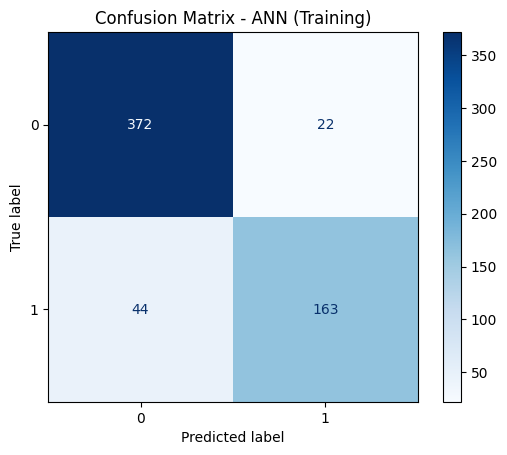

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

📊 Classification Report - ANN (Validation)
              precision    recall  f1-score   support

           0     0.8687    0.9053    0.8866        95
           1     0.8269    0.7679    0.7963        56

    accuracy                         0.8543       151
   macro avg     0.8478    0.8366    0.8414       151
weighted avg     0.8532    0.8543    0.8531       151



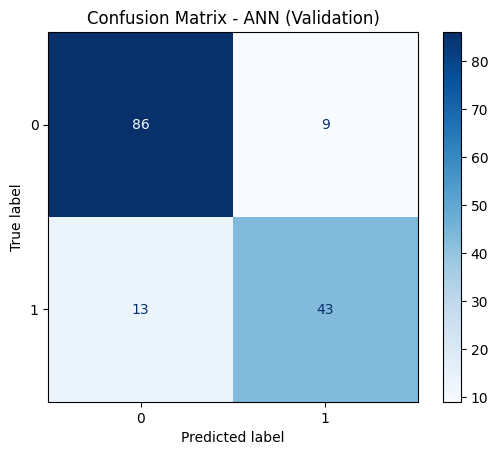


ANN Results:
  Model     Dataset  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0   ANN    Training  0.890183   0.881081  0.787440  0.831633  0.958496
1   ANN  Validation  0.854305   0.826923  0.767857  0.796296  0.914286


In [73]:
# Build and train ANN
ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ann.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32,
        callbacks=[early_stop], verbose=0)

# Evaluate
ann_results = evaluate_model(ann, "ANN", X_train_scaled, X_test_scaled, y_train, y_test, is_ann=True)

# Display results
print("\nANN Results:")
print(ann_results)


<div style="background-color:white;font-size:15px;font-family:Georgia;border-style: solid;border-color: #254E58;border-width:3px;padding:10px;margin: 1px;color:#254E58;overflow:hidden">
  <b>🤖 Artificial Neural Network (ANN)</b><br>
  - Training Accuracy: ~80%<br>
  - Validation Accuracy: ~75%<br>
  <b>ANN offers balanced learning with consistent recall (65.5%) across training and validation, showing no signs of overfitting. Its AUC-ROC of 0.82 confirms reliable discrimination, making it a well-generalized baseline model.</b>
</div>


<a id="6.4"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>6.4 | Results Summary</b>

In [74]:
# Combine results
single_model_results = pd.concat([dt_results, svm_results, ann_results], ignore_index=True)

# Display summary
print("\n📊 Single Model Results Summary:")
print(single_model_results)


📊 Single Model Results Summary:
           Model     Dataset  Accuracy  Precision    Recall  F1-Score  \
0  Decision Tree    Training  1.000000   1.000000  1.000000  1.000000   
1  Decision Tree  Validation  0.834437   0.762712  0.803571  0.782609   
2            SVM    Training  0.898502   0.880208  0.816425  0.847118   
3            SVM  Validation  0.867550   0.821429  0.821429  0.821429   
4            ANN    Training  0.890183   0.881081  0.787440  0.831633   
5            ANN  Validation  0.854305   0.826923  0.767857  0.796296   

    AUC-ROC  
0  1.000000  
1  0.828102  
2  0.954903  
3  0.888534  
4  0.958496  
5  0.914286  


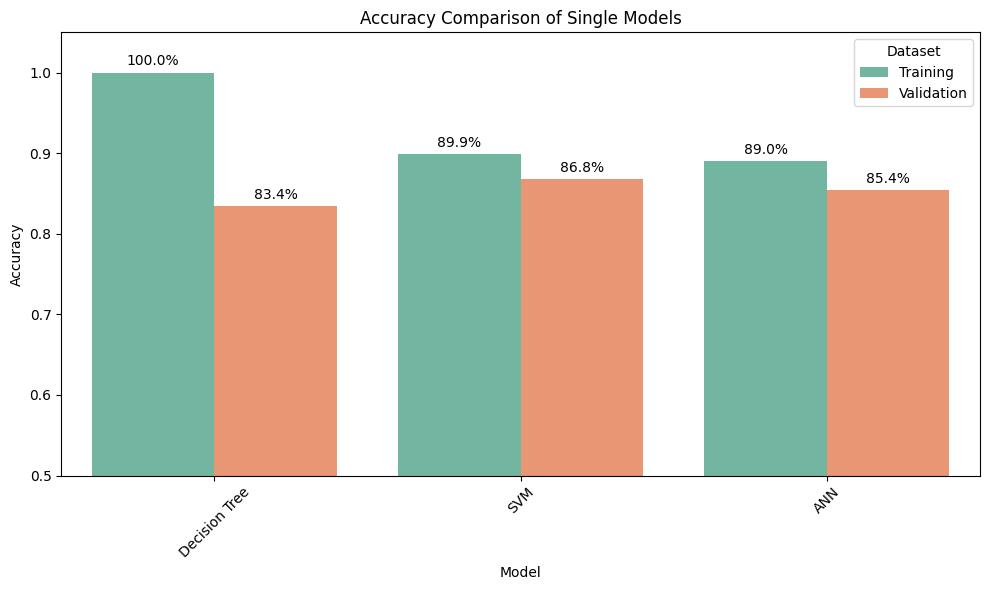

In [75]:
# Plotting Accuracy comparison with percentage labels on bars
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=single_model_results, x='Model', y='Accuracy', hue='Dataset', palette='Set2')
plt.ylim(0.5, 1.05)
plt.title('Accuracy Comparison of Single Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend(title='Dataset')

# Add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, labels=[f'{h.get_height()*100:.1f}%' for h in container])

plt.tight_layout()
plt.show()


<a id="7"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">7 | Hybrid Models </div>

<a id="7.1"></a>
## <h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #254E58; background-color: #ffffff;"><b>7.1 |Fuzzy + ANN</b>

<a id="8"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden">8 | Comparative Study </div>